# 🧹 Data Cleaning & Preprocessing — Review iPhone 17 Tokopedia

**Tujuan notebook ini:**
- Membersihkan data hasil scraping dari noise, duplikat, dan entri tidak valid
- Melabeli sentimen berdasarkan rating (Positif / Netral / Negatif)
- Melakukan text preprocessing untuk keperluan pemodelan NLP
- Menghasilkan visualisasi di setiap tahap untuk keperluan laporan skripsi

**Input:** `data/raw/tokopedia_reviews_new.csv` (1514 reviews)  
**Output:** `data/processed/tokopedia_reviews_clean.csv` (≥1500 clean reviews)

---
> **Proyek:** Analisis Sentimen dengan XAI (LIME vs SHAP) — Skripsi 2026

## 1️⃣ Setup — Import Libraries & Konfigurasi

In [1]:
# Install library yang dibutuhkan (jalankan sekali)
%pip install matplotlib seaborn wordcloud PySastrawi --quiet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: D:\xai_lime_vs_shap\venv312\Scripts\python.exe -m pip install --upgrade pip


In [2]:
import os, sys, re, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")

# Path setup — bekerja baik dari dalam maupun luar folder notebooks/
project_root = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
sys.path.insert(0, project_root)

from src.preprocessing.cleaner import (
    remove_duplicates, drop_empty_reviews, filter_valid_ratings,
    clean_variant, add_sentiment_label, apply_text_cleaning,
    apply_stemming, drop_unused_columns
)

# Direktori output
FIGURES_DIR   = os.path.join(project_root, "outputs", "figures")
PROCESSED_DIR = os.path.join(project_root, "data", "processed")
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(PROCESSED_DIR, exist_ok=True)

INPUT_PATH  = os.path.join(project_root, "data", "raw", "tokopedia_reviews_new.csv")
OUTPUT_PATH = os.path.join(PROCESSED_DIR, "tokopedia_reviews_clean.csv")

# Style visual konsisten
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

print("✅ Setup selesai!")
print(f"📁 Project root : {project_root}")
print(f"🗂️  Input        : {INPUT_PATH}")
print(f"💾 Output       : {OUTPUT_PATH}")
print(f"🖼️  Figures dir  : {FIGURES_DIR}")

✅ Setup selesai!
📁 Project root : D:\xai_lime_vs_shap
🗂️  Input        : D:\xai_lime_vs_shap\data\raw\tokopedia_reviews_new.csv
💾 Output       : D:\xai_lime_vs_shap\data\processed\tokopedia_reviews_clean.csv
🖼️  Figures dir  : D:\xai_lime_vs_shap\outputs\figures


## 2️⃣ Load & Inspeksi Data Mentah

In [3]:
df_raw = pd.read_csv(INPUT_PATH)

print(f"📊 Shape       : {df_raw.shape}")
print(f"📋 Kolom       : {df_raw.columns.tolist()}")
print(f"\n📌 5 baris pertama:")
df_raw.head()

📊 Shape       : (1558, 11)
📋 Kolom       : ['product_url', 'product_name', 'store_name', 'reviewer_name', 'rating', 'review_text', 'review_date', 'variant', 'helpful_count', 'scraped_at', 'review_id']

📌 5 baris pertama:


,product_url,product_name,store_name,reviewer_name,rating,review_text,review_date,variant,helpful_count,scraped_at,review_id
0,https://www.tokopedia.com/milano-cell/fs-milan...,[FS MILANO] Apple iPhone 17 256GB Garansi Resm...,Unknown,E***s,5,Akhirnya barang yang ditunggu-tunggu datang ju...,Lebih dari 1 tahun lalu,Varian: Black,0,2026-01-12T20:28:42.369832,98125386393a
1,https://www.tokopedia.com/milano-cell/fs-milan...,[FS MILANO] Apple iPhone 17 256GB Garansi Resm...,Unknown,Anonymous,5,Barang sudah sampai resmi Indonesia kode SA/A ...,Lebih dari 1 tahun lalu,Varian: White,0,2026-01-12T20:28:42.369832,c363bec1b74e
2,https://www.tokopedia.com/milano-cell/fs-milan...,[FS MILANO] Apple iPhone 17 256GB Garansi Resm...,Unknown,Anonymous,5,"PO pas 12.12 dapt harga 7.526 hehhe, nunggu 2 ...",Lebih dari 1 tahun lalu,Varian: Black,0,2026-01-12T20:28:42.369832,143019058fc2
3,https://www.tokopedia.com/milano-cell/fs-milan...,[FS MILANO] Apple iPhone 17 256GB Garansi Resm...,Unknown,Anonymous,5,Barang mendarat dengan selamat original ibox a...,Lebih dari 1 tahun lalu,Varian: Red,0,2026-01-12T20:28:42.369832,acc3b1586f89
4,https://www.tokopedia.com/milano-cell/fs-milan...,[FS MILANO] Apple iPhone 17 256GB Garansi Resm...,Unknown,r***r,5,Nilai uang: Worth it Dibandingkan dengan deskr...,Lebih dari 1 tahun lalu,Varian: Purple,0,2026-01-12T20:28:42.369832,76df08c4987e


In [4]:
print("=== Info Tipe Data ===")
df_raw.info()
print("\n=== Statistik Deskriptif ===")
df_raw[["rating", "helpful_count"]].describe()

=== Info Tipe Data ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1558 entries, 0 to 1557
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   product_url    1558 non-null   object
 1   product_name   1558 non-null   object
 2   store_name     1558 non-null   object
 3   reviewer_name  1558 non-null   object
 4   rating         1558 non-null   int64 
 5   review_text    1558 non-null   object
 6   review_date    1555 non-null   object
 7   variant        1511 non-null   object
 8   helpful_count  1558 non-null   int64 
 9   scraped_at     1558 non-null   object
 10  review_id      1558 non-null   object
dtypes: int64(2), object(9)
memory usage: 134.0+ KB

=== Statistik Deskriptif ===


,rating,helpful_count
count,1558.000000,1558.0
mean,4.865854,0.0
std,0.683301,0.0
min,1.000000,0.0
25%,5.000000,0.0
50%,5.000000,0.0
75%,5.000000,0.0
max,5.000000,0.0


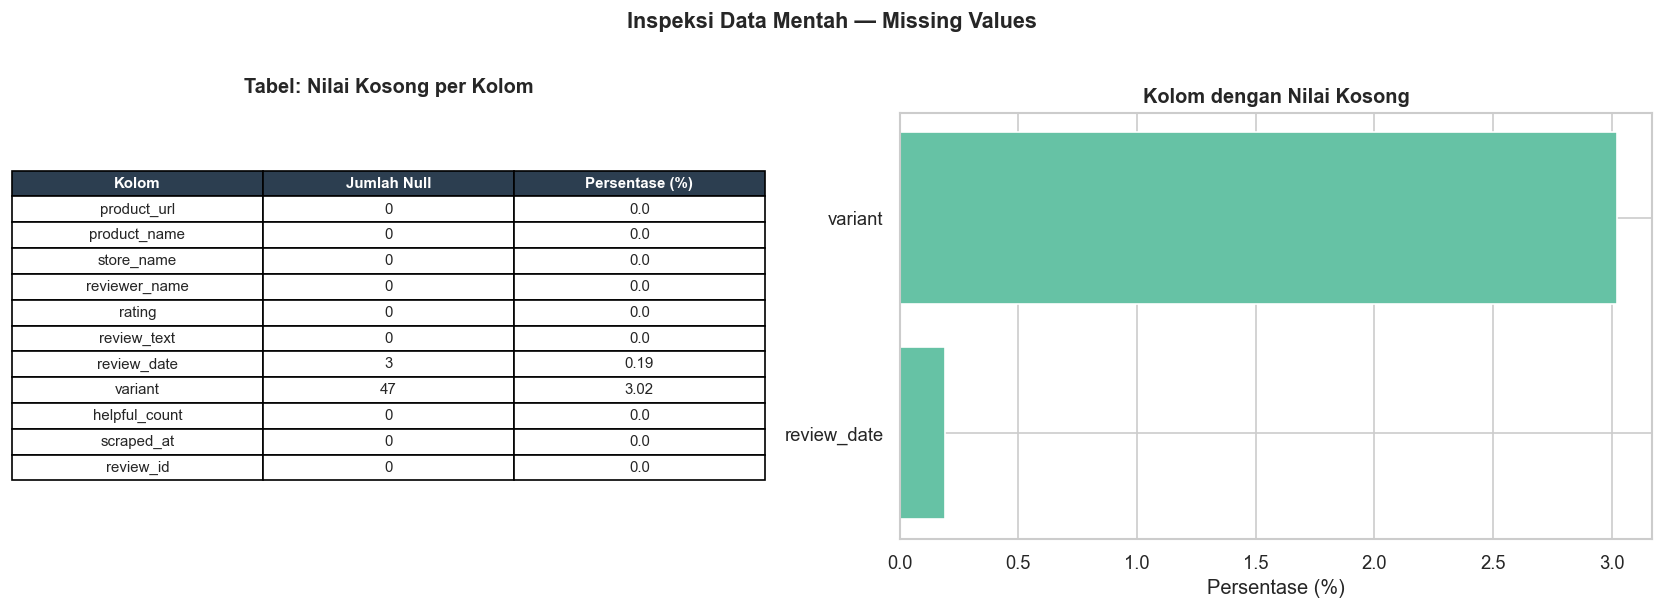

✅ Gambar disimpan: outputs/figures/01_missing_values.png


In [5]:
# --- VISUAL 1: Missing Values ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

null_counts = df_raw.isnull().sum().reset_index()
null_counts.columns = ["Kolom", "Jumlah Null"]
null_counts["Persentase"] = (null_counts["Jumlah Null"] / len(df_raw) * 100).round(2)

# Kiri: tabel null
axes[0].axis("off")
tbl = axes[0].table(
    cellText=null_counts[["Kolom", "Jumlah Null", "Persentase"]].values.tolist(),
    colLabels=["Kolom", "Jumlah Null", "Persentase (%)"],
    loc="center", cellLoc="center"
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.4)
for j in range(3):
    tbl[(0, j)].set_facecolor("#2c3e50")
    tbl[(0, j)].set_text_props(color="white", fontweight="bold")
axes[0].set_title("Tabel: Nilai Kosong per Kolom", fontweight="bold", pad=12)

# Kanan: bar chart kolom dengan null
cols_with_null = null_counts[null_counts["Jumlah Null"] > 0]
if len(cols_with_null) > 0:
    axes[1].barh(cols_with_null["Kolom"], cols_with_null["Persentase"],
                 color=sns.color_palette("Set2")[0])
    axes[1].set_xlabel("Persentase (%)")
    axes[1].set_title("Kolom dengan Nilai Kosong", fontweight="bold")
else:
    axes[1].text(0.5, 0.5, "Tidak ada nilai kosong! ✅",
                 ha="center", va="center", fontsize=13,
                 transform=axes[1].transAxes)
    axes[1].axis("off")

plt.suptitle("Inspeksi Data Mentah — Missing Values", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "01_missing_values.png"), bbox_inches="tight")
plt.show()
print("✅ Gambar disimpan: outputs/figures/01_missing_values.png")

## 3️⃣ Cleaning Struktural

Langkah-langkah:
1. Hapus duplikat berdasarkan `review_id`
2. Hapus baris dengan `review_text` kosong (setelah trim)
3. Hapus baris dengan `rating` tidak valid (di luar 1–5)
4. Bersihkan kolom `variant` (hapus prefix "Varian: ")

In [6]:
# Catat jumlah baris setiap langkah untuk log visualisasi
drop_log = {"Raw": len(df_raw)}

print("🔄 Memulai Structural Cleaning...")
print(f"   Awal   : {len(df_raw)} baris\n")

df = df_raw.copy()

df = remove_duplicates(df)
drop_log["Setelah\nDeduplikasi"] = len(df)
print(f"   Setelah deduplikasi    : {len(df)} baris  (−{drop_log['Raw'] - len(df)})")

df = drop_empty_reviews(df, min_chars=1)
drop_log["Setelah Drop\nReview Kosong"] = len(df)
print(f"   Setelah drop kosong    : {len(df)} baris  (−{list(drop_log.values())[-2] - len(df)})")

df = filter_valid_ratings(df)
drop_log["Setelah\nFilter Rating"] = len(df)
print(f"   Setelah filter rating  : {len(df)} baris  (−{list(drop_log.values())[-2] - len(df)})")

df = clean_variant(df)
drop_log["Setelah\nClean Variant"] = len(df)
print(f"   Setelah clean variant  : {len(df)} baris  (−{list(drop_log.values())[-2] - len(df)})")

print(f"\n✅ Structural cleaning selesai: {len(df_raw)} → {len(df)} baris")
print(f"\nContoh variant setelah dibersihkan:")
print(df["variant"].value_counts().head(8))

🔄 Memulai Structural Cleaning...
   Awal   : 1558 baris

  [dedupe]     1558 →  1558  (removed 0)
   Setelah deduplikasi    : 1558 baris  (−0)
  [empty/short]  1558 →  1558  (removed 0, min_chars=1)
   Setelah drop kosong    : 1558 baris  (−0)
  [rating]     1558 →  1558  (removed 0)
   Setelah filter rating  : 1558 baris  (−0)
   Setelah clean variant  : 1558 baris  (−0)

✅ Structural cleaning selesai: 1558 → 1558 baris

Contoh variant setelah dibersihkan:
variant
Black                    185
Promo Natural - 128GB    138
White                    121
A                         57
Promo Blue - 128GB        48
Promo Black - 128GB       40
256GB - Mist Blue         40
Promo Natural - 256GB     38
Name: count, dtype: int64


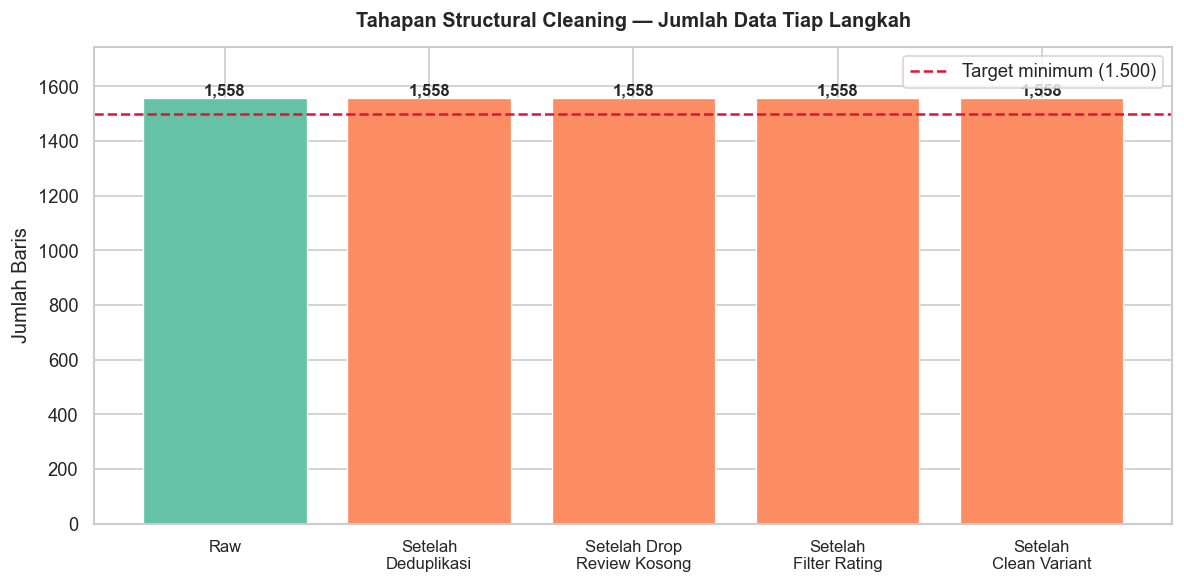

✅ Gambar disimpan: outputs/figures/02_drop_log.png


In [7]:
# --- VISUAL 2: Drop Log — Jumlah Data Tiap Langkah Cleaning ---
fig, ax = plt.subplots(figsize=(10, 5))

labels = list(drop_log.keys())
values = list(drop_log.values())
colors = [sns.color_palette("Set2")[0]] + [sns.color_palette("Set2")[1]] * (len(labels) - 1)

bars = ax.bar(range(len(labels)), values, color=colors, edgecolor="white", linewidth=0.8)

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            f"{val:,}", ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.axhline(1500, color="crimson", linestyle="--", linewidth=1.5, label="Target minimum (1.500)")
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=0, ha="center", fontsize=10)
ax.set_ylabel("Jumlah Baris")
ax.set_title("Tahapan Structural Cleaning — Jumlah Data Tiap Langkah",
             fontweight="bold", pad=12)
ax.set_ylim(0, max(values) * 1.12)
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "02_drop_log.png"), bbox_inches="tight")
plt.show()
print("✅ Gambar disimpan: outputs/figures/02_drop_log.png")

## 4️⃣ Labeling Sentimen

Mapping rating → label sentimen:

| Rating | Sentimen |
|--------|----------|
| 4 – 5  | Positif  |
| 3      | Netral   |
| 1 – 2  | Negatif  |

In [8]:
df = add_sentiment_label(df)

print("📊 Distribusi Label Sentimen:")
print(df["sentiment_label"].value_counts())
print()
print("📊 Distribusi Rating:")
print(df["rating"].value_counts().sort_index())

  [sentiment] Positif=1497  Netral=12  Negatif=49
📊 Distribusi Label Sentimen:
sentiment_label
Positif    1497
Negatif      49
Netral       12
Name: count, dtype: int64

📊 Distribusi Rating:
rating
1      38
2      11
3      12
5    1497
Name: count, dtype: int64


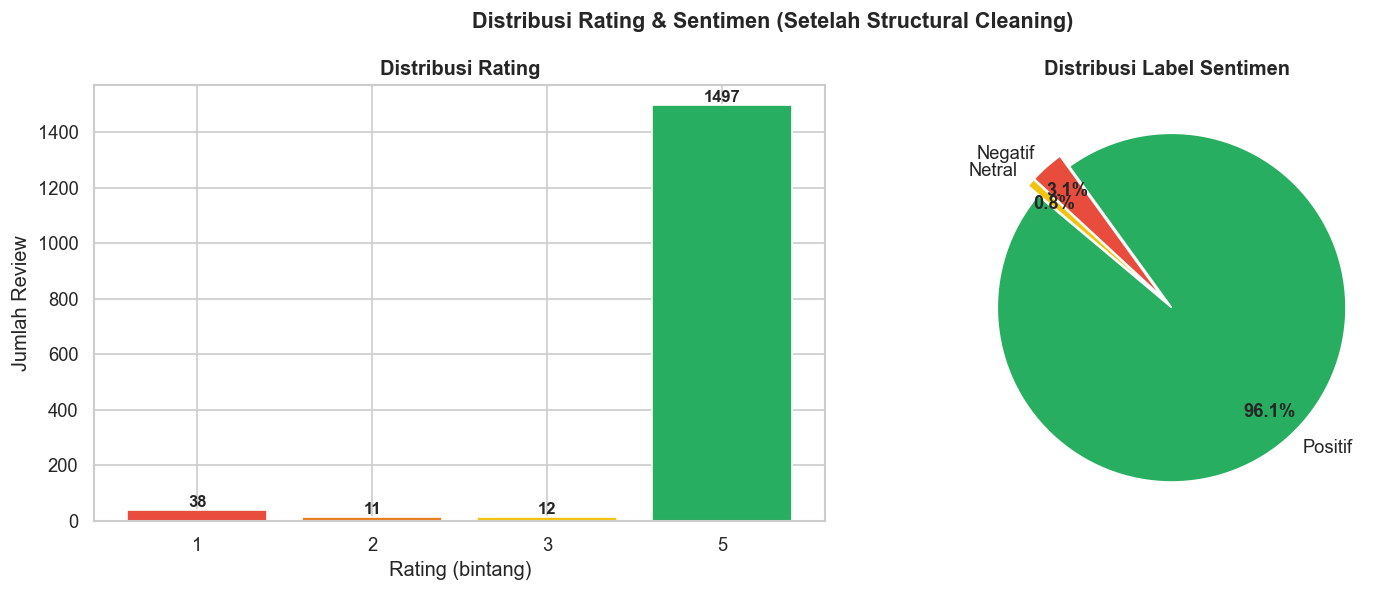

✅ Gambar disimpan: outputs/figures/03_rating_sentimen.png


In [9]:
# --- VISUAL 3: Distribusi Rating & Sentimen ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Kiri: bar chart distribusi rating
rating_dist = df["rating"].value_counts().sort_index()
palette_r   = {1: "#e74c3c", 2: "#e67e22", 3: "#f1c40f", 4: "#2ecc71", 5: "#27ae60"}
bars = axes[0].bar(rating_dist.index.astype(str), rating_dist.values,
                   color=[palette_r[r] for r in rating_dist.index], edgecolor="white")
for bar, val in zip(bars, rating_dist.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
                 str(val), ha="center", va="bottom", fontsize=10, fontweight="bold")
axes[0].set_xlabel("Rating (bintang)")
axes[0].set_ylabel("Jumlah Review")
axes[0].set_title("Distribusi Rating", fontweight="bold")

# Kanan: pie chart sentimen
sent_dist = df["sentiment_label"].value_counts()
palette_s  = {"Positif": "#27ae60", "Netral": "#f1c40f", "Negatif": "#e74c3c"}
colors_s   = [palette_s.get(l, "#95a5a6") for l in sent_dist.index]
wedges, texts, autotexts = axes[1].pie(
    sent_dist.values,
    labels=sent_dist.index,
    autopct="%1.1f%%",
    startangle=140,
    colors=colors_s,
    explode=[0.04] * len(sent_dist),
    pctdistance=0.82,
    textprops={"fontsize": 11}
)
for at in autotexts:
    at.set_fontweight("bold")
axes[1].set_title("Distribusi Label Sentimen", fontweight="bold")

plt.suptitle("Distribusi Rating & Sentimen (Setelah Structural Cleaning)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "03_rating_sentimen.png"), bbox_inches="tight")
plt.show()
print("✅ Gambar disimpan: outputs/figures/03_rating_sentimen.png")

## 5️⃣ Text Preprocessing

Langkah pemrosesan teks:
1. Simpan teks asli ke `review_text_raw`
2. Lowercase
3. Hapus URL, mention (`@...`), hashtag (`#...`)
4. Hapus karakter non-alfanumerik kecuali spasi (emoji, tanda baca khusus)
5. Normalisasi spasi ganda/leading/trailing
6. Simpan hasil ke `review_text_clean`
7. Hitung `text_length` (jumlah kata) & hapus baris dengan < 1 kata (teks kosong setelah cleaning)

In [10]:
# Simpan distribusi panjang teks SEBELUM cleaning untuk perbandingan
len_before = df["review_text"].dropna().str.split().str.len()

df = apply_text_cleaning(df, min_words=1)
drop_log["Setelah Text\nPreprocessing"] = len(df)

print(f"✅ Text preprocessing selesai: {len(df)} baris tersisa")
print(f"\nStatistik panjang teks setelah preprocessing (kata):")
print(df["text_length"].describe().round(2))

# Tampilkan 3 contoh before/after
print("\n=== Contoh Teks: Raw vs Clean ===\n")
sample = df[["review_text_raw", "review_text_clean", "rating", "sentiment_label"]].sample(3, random_state=42)
for i, row in sample.iterrows():
    print(f"[Rating {row['rating']} — {row['sentiment_label']}]")
    print(f"  RAW  : {str(row['review_text_raw'])[:130]}")
    print(f"  BERSIH: {str(row['review_text_clean'])[:130]}")
    print()

  [text_len]   1558 →  1556  (removed 2, min_words=1)
✅ Text preprocessing selesai: 1556 baris tersisa

Statistik panjang teks setelah preprocessing (kata):
count    1556.00
mean       11.89
std         8.41
min         1.00
25%         5.00
50%        10.00
75%        18.00
max        34.00
Name: text_length, dtype: float64

=== Contoh Teks: Raw vs Clean ===

[Rating 5 — Positif]
  RAW  : selalu puas beli disini. Rekomendasi seller
  BERSIH: selalu puas beli disini rekomendasi seller

[Rating 5 — Positif]
  RAW  : Rekomondasi pokoknya beli di toko ini ngga nyesel asli real garasi resmi iBox packingan bagus tebel 2x bungkus
  BERSIH: rekomondasi pokoknya beli di toko ini ngga nyesel asli real garasi resmi ibox packingan bagus tebel 2x bungkus

[Rating 5 — Positif]
  RAW  : Barangnyaa udah sampaii, admin responsif dan okee
  BERSIH: barangnyaa udah sampaii admin responsif dan okee



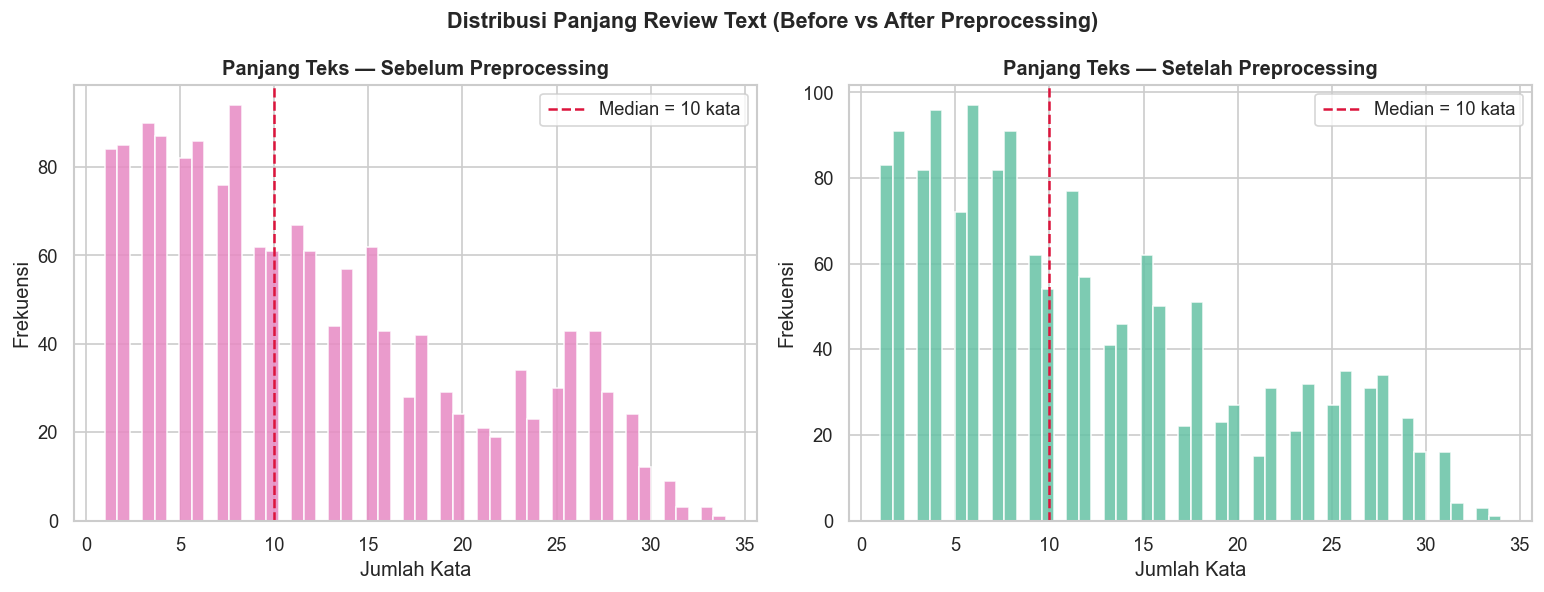

✅ Gambar disimpan: outputs/figures/04_text_length_dist.png


In [11]:
# --- VISUAL 4: Distribusi Panjang Teks Before vs After ---
len_after = df["text_length"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Kiri: sebelum cleaning
axes[0].hist(len_before, bins=50, color=sns.color_palette("Set2")[3],
             edgecolor="white", alpha=0.85)
axes[0].axvline(len_before.median(), color="crimson", linestyle="--",
                label=f"Median = {len_before.median():.0f} kata")
axes[0].set_xlabel("Jumlah Kata")
axes[0].set_ylabel("Frekuensi")
axes[0].set_title("Panjang Teks — Sebelum Preprocessing", fontweight="bold")
axes[0].legend()

# Kanan: setelah cleaning
axes[1].hist(len_after, bins=50, color=sns.color_palette("Set2")[0],
             edgecolor="white", alpha=0.85)
axes[1].axvline(len_after.median(), color="crimson", linestyle="--",
                label=f"Median = {len_after.median():.0f} kata")
axes[1].set_xlabel("Jumlah Kata")
axes[1].set_ylabel("Frekuensi")
axes[1].set_title("Panjang Teks — Setelah Preprocessing", fontweight="bold")
axes[1].legend()

plt.suptitle("Distribusi Panjang Review Text (Before vs After Preprocessing)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "04_text_length_dist.png"), bbox_inches="tight")
plt.show()
print("✅ Gambar disimpan: outputs/figures/04_text_length_dist.png")

## 6️⃣ Analisis Distribusi Data (untuk Laporan Skripsi)

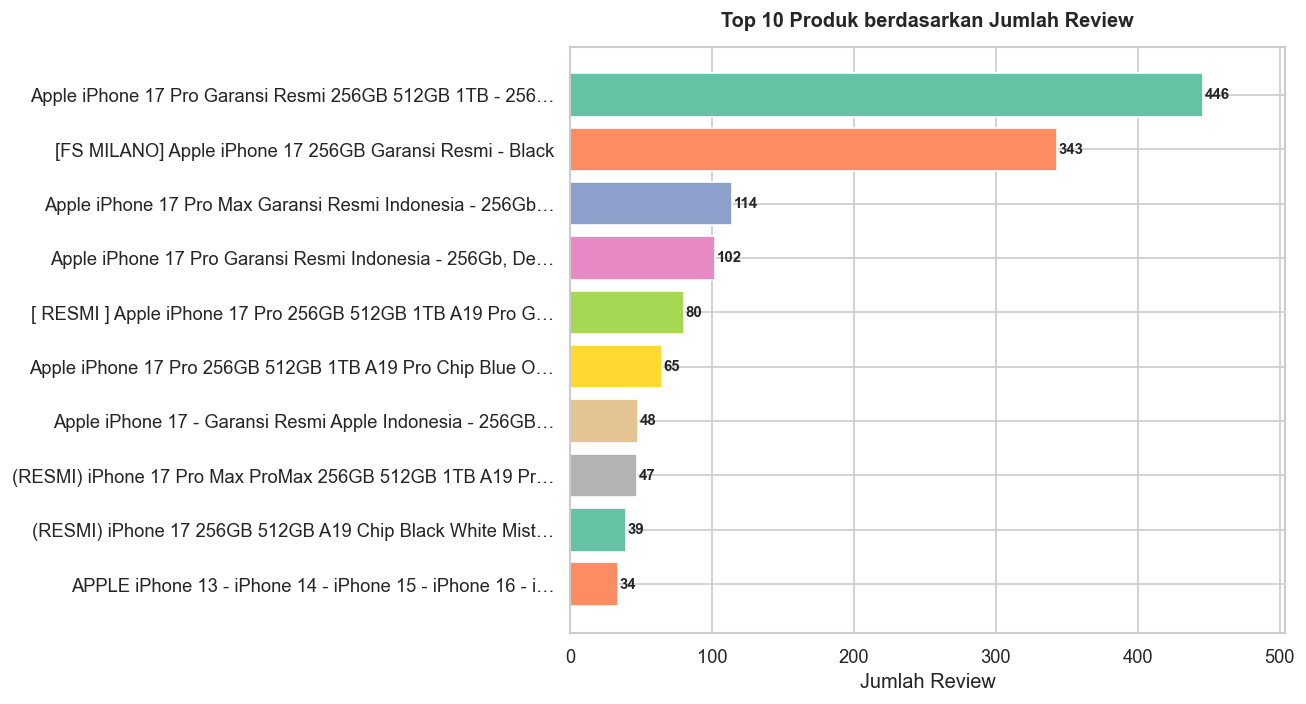

✅ Gambar disimpan: outputs/figures/05_top10_products.png


In [12]:
# --- VISUAL 5: Top 10 Produk berdasarkan Jumlah Review ---
fig, ax = plt.subplots(figsize=(11, 6))

top10 = df["product_name"].value_counts().head(10)
short_names = [name[:55] + "…" if len(name) > 55 else name for name in top10.index]

bars = ax.barh(short_names[::-1], top10.values[::-1],
               color=sns.color_palette("Set2", 10)[::-1], edgecolor="white")
for bar, val in zip(bars, top10.values[::-1]):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
            str(val), va="center", fontsize=9, fontweight="bold")

ax.set_xlabel("Jumlah Review")
ax.set_title("Top 10 Produk berdasarkan Jumlah Review", fontweight="bold", pad=12)
ax.set_xlim(0, top10.max() * 1.13)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "05_top10_products.png"), bbox_inches="tight")
plt.show()
print("✅ Gambar disimpan: outputs/figures/05_top10_products.png")

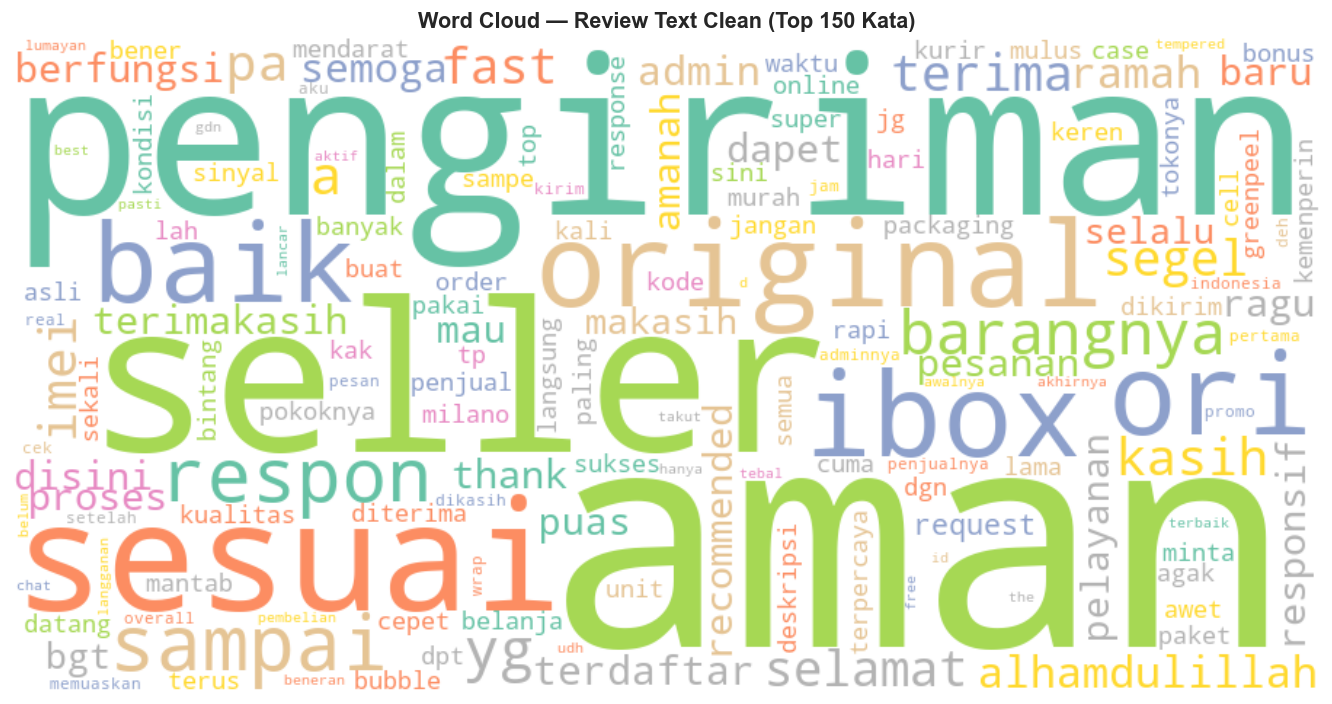

✅ Gambar disimpan: outputs/figures/06_wordcloud.png


In [13]:
# --- VISUAL 6: Word Cloud ---
try:
    from wordcloud import WordCloud

    all_text = " ".join(df["review_text_clean"].dropna())

    # Stopwords Bahasa Indonesia (manual)
    id_stopwords = {
        "yang", "dan", "di", "ke", "dari", "ini", "itu", "dengan", "untuk",
        "tidak", "ada", "saya", "juga", "sudah", "bisa", "pada", "tapi",
        "nya", "ga", "gak", "ya", "aja", "banget", "sangat", "nih", "loh",
        "si", "sih", "kalo", "kalau", "udah", "memang", "karena", "jadi",
        "atau", "lebih", "seperti", "kita", "punya", "barang", "produk",
        "beli", "dapat", "harga", "lagi", "sama", "masih", "warna", "via",
        "resmi", "iphone", "apple", "garansi", "toko", "hp", "handphone",
        "good", "bagus", "packing", "mantap", "oke", "ok", "mantul", "cepat"
    }

    wc = WordCloud(
        width=900, height=450, background_color="white",
        max_words=150, colormap="Set2",
        stopwords=id_stopwords, collocations=False, random_state=42
    ).generate(all_text)

    fig, ax = plt.subplots(figsize=(13, 6))
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title("Word Cloud — Review Text Clean (Top 150 Kata)",
                 fontweight="bold", fontsize=13)
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, "06_wordcloud.png"), bbox_inches="tight")
    plt.show()
    print("✅ Gambar disimpan: outputs/figures/06_wordcloud.png")

except ImportError:
    print("⚠️  WordCloud belum terinstall. Jalankan: pip install wordcloud")

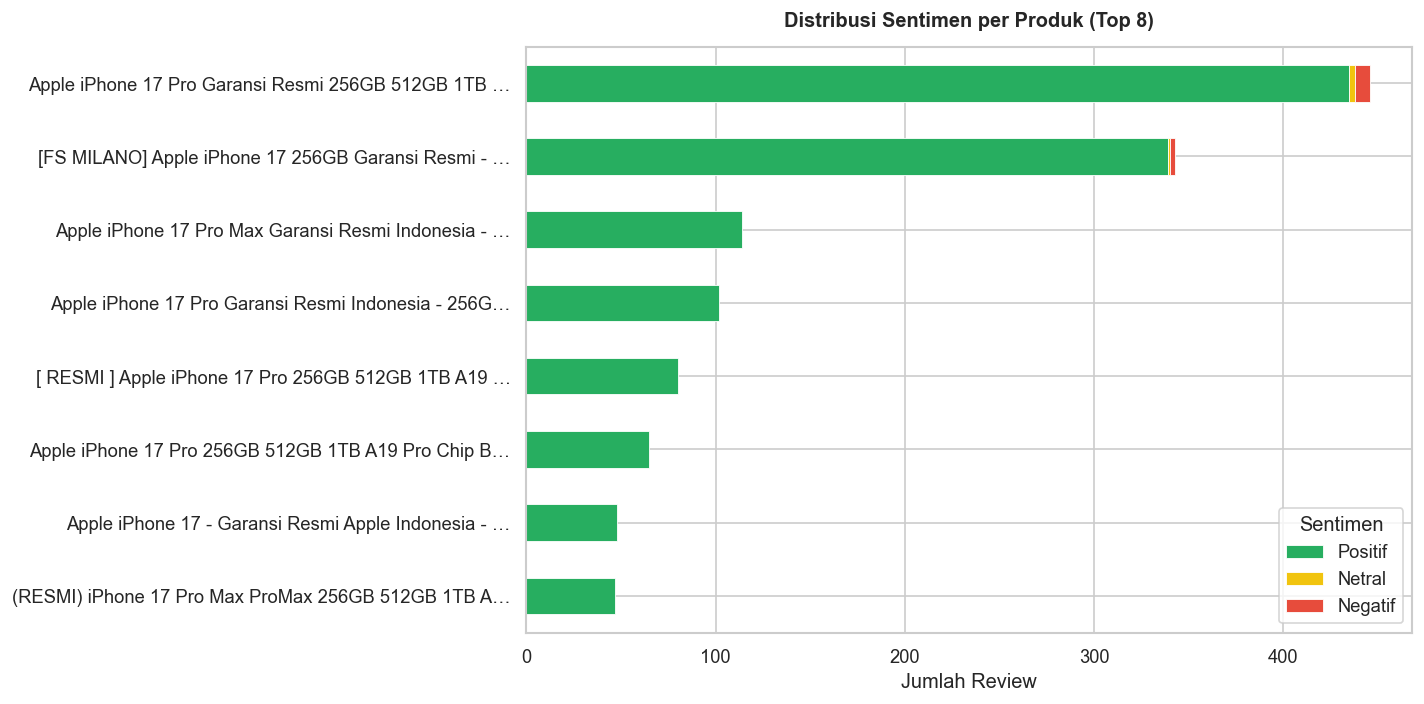

✅ Gambar disimpan: outputs/figures/07_sentimen_per_produk.png


In [14]:
# --- VISUAL 7: Distribusi Sentimen per Produk (Top 8, stacked bar) ---
top8_products = df["product_name"].value_counts().head(8).index
df_top8       = df[df["product_name"].isin(top8_products)]

pivot = pd.crosstab(df_top8["product_name"], df_top8["sentiment_label"])
for col in ["Positif", "Netral", "Negatif"]:
    if col not in pivot.columns:
        pivot[col] = 0
pivot = pivot[["Positif", "Netral", "Negatif"]]

# Urutkan berdasarkan total review (terbanyak di atas)
pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=True).index]
short_idx = [name[:50] + "…" if len(name) > 50 else name for name in pivot.index]
pivot.index = short_idx

fig, ax = plt.subplots(figsize=(12, 6))
pivot.plot(kind="barh", stacked=True, ax=ax,
           color=["#27ae60", "#f1c40f", "#e74c3c"],
           edgecolor="white", linewidth=0.5)
ax.set_xlabel("Jumlah Review")
ax.set_title("Distribusi Sentimen per Produk (Top 8)", fontweight="bold", pad=12)
ax.legend(loc="lower right", title="Sentimen")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "07_sentimen_per_produk.png"), bbox_inches="tight")
plt.show()
print("✅ Gambar disimpan: outputs/figures/07_sentimen_per_produk.png")

## 7️⃣ Finalisasi & Export

- Hapus kolom tidak informatif untuk pemodelan (`helpful_count`, `scraped_at`, `product_url`)
- Simpan dataset bersih ke `data/processed/tokopedia_reviews_clean.csv`

In [15]:
df = drop_unused_columns(df)

print("📋 Kolom final yang disimpan:")
for col in df.columns:
    print(f"   • {col}")

print(f"\n📊 Shape final: {df.shape}")
print(f"\n🔍 Null check:")
print(df.isnull().sum())

# Export
df.to_csv(OUTPUT_PATH, index=False, encoding="utf-8")
print(f"\n✅ Dataset bersih disimpan: {OUTPUT_PATH}")
print(f"   → {len(df):,} baris  ×  {df.shape[1]} kolom")

  [drop_cols] Removed: ['helpful_count', 'scraped_at', 'product_url']
📋 Kolom final yang disimpan:
   • product_name
   • store_name
   • reviewer_name
   • rating
   • review_text
   • review_date
   • variant
   • review_id
   • sentiment_label
   • review_text_raw
   • review_text_clean
   • text_length

📊 Shape final: (1556, 12)

🔍 Null check:
product_name          0
store_name            0
reviewer_name         0
rating                0
review_text           0
review_date           3
variant              47
review_id             0
sentiment_label       0
review_text_raw       0
review_text_clean     0
text_length           0
dtype: int64

✅ Dataset bersih disimpan: D:\xai_lime_vs_shap\data\processed\tokopedia_reviews_clean.csv
   → 1,556 baris  ×  12 kolom


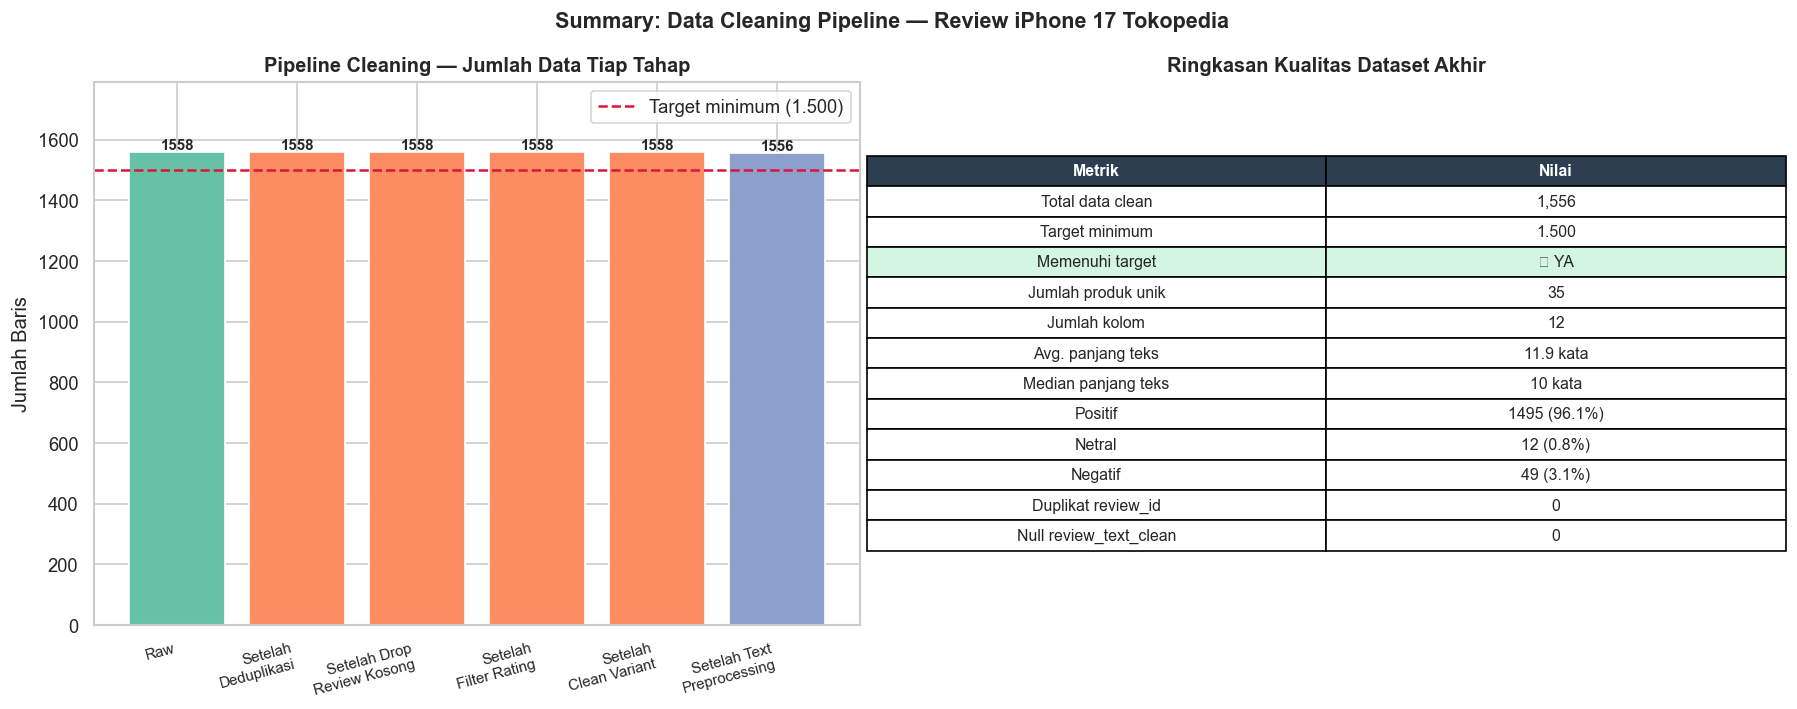

✅ Gambar disimpan: outputs/figures/08_summary_cleaning.png


In [16]:
# --- VISUAL 8: Summary Akhir Pipeline ---
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Kiri: bar chart full drop log
dl_labels = list(drop_log.keys())
dl_values = list(drop_log.values())
pal = sns.color_palette("Set2")
bar_colors = [pal[0]] + [pal[1]] * (len(dl_labels) - 2) + [pal[2]]

bars = axes[0].bar(range(len(dl_labels)), dl_values, color=bar_colors, edgecolor="white")
for bar, val in zip(bars, dl_values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                 f"{val}", ha="center", va="bottom", fontsize=9, fontweight="bold")
axes[0].axhline(1500, color="crimson", linestyle="--",
                linewidth=1.5, label="Target minimum (1.500)")
axes[0].set_xticks(range(len(dl_labels)))
axes[0].set_xticklabels(dl_labels, rotation=15, ha="right", fontsize=9)
axes[0].set_ylabel("Jumlah Baris")
axes[0].set_title("Pipeline Cleaning — Jumlah Data Tiap Tahap", fontweight="bold")
axes[0].set_ylim(0, max(dl_values) * 1.15)
axes[0].legend()

# Kanan: tabel statistik kualitas akhir
clean_n = len(df)
n_pos  = (df["sentiment_label"] == "Positif").sum()
n_net  = (df["sentiment_label"] == "Netral").sum()
n_neg  = (df["sentiment_label"] == "Negatif").sum()

summary_rows = [
    ["Total data clean",      f"{clean_n:,}"],
    ["Target minimum",        "1.500"],
    ["Memenuhi target",       "✅ YA" if clean_n >= 1500 else "❌ TIDAK"],
    ["Jumlah produk unik",    str(df["product_name"].nunique())],
    ["Jumlah kolom",          str(df.shape[1])],
    ["Avg. panjang teks",     f"{df['text_length'].mean():.1f} kata"],
    ["Median panjang teks",   f"{df['text_length'].median():.0f} kata"],
    ["Positif",               f"{n_pos} ({n_pos/clean_n*100:.1f}%)"],
    ["Netral",                f"{n_net} ({n_net/clean_n*100:.1f}%)"],
    ["Negatif",               f"{n_neg} ({n_neg/clean_n*100:.1f}%)"],
    ["Duplikat review_id",    str(df["review_id"].duplicated().sum())],
    ["Null review_text_clean",str(df["review_text_clean"].isnull().sum())],
]

axes[1].axis("off")
tbl = axes[1].table(cellText=summary_rows, colLabels=["Metrik", "Nilai"],
                    loc="center", cellLoc="center")
tbl.auto_set_font_size(False)
tbl.set_fontsize(9.5)
tbl.scale(1.2, 1.55)
for j in range(2):
    tbl[(0, j)].set_facecolor("#2c3e50")
    tbl[(0, j)].set_text_props(color="white", fontweight="bold")
tbl[(3, 0)].set_facecolor("#d5f5e3")
tbl[(3, 1)].set_facecolor("#d5f5e3")
axes[1].set_title("Ringkasan Kualitas Dataset Akhir", fontweight="bold")

plt.suptitle("Summary: Data Cleaning Pipeline — Review iPhone 17 Tokopedia",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "08_summary_cleaning.png"), bbox_inches="tight")
plt.show()
print("✅ Gambar disimpan: outputs/figures/08_summary_cleaning.png")

## 8️⃣ Validasi & Cek Kualitas Akhir

In [17]:
print("=" * 50)
print("  VALIDASI DATASET FINAL")
print("=" * 50)

checks = []

# 1. Jumlah minimum
ok = len(df) >= 1500
checks.append(("Jumlah baris ≥ 1500", ok, f"{len(df):,} baris"))
print(f"{'✅' if ok else '❌'}  Jumlah baris ≥ 1500 : {len(df):,}")

# 2. Tidak ada duplikat review_id
dups = df["review_id"].duplicated().sum()
ok = dups == 0
checks.append(("Tidak ada duplikat review_id", ok, f"{dups} duplikat"))
print(f"{'✅' if ok else '❌'}  Tidak ada duplikat  : {dups} duplikat ditemukan")

# 3. Tidak ada null pada kolom kritis
for col in ["review_text_clean", "sentiment_label", "rating"]:
    n_null = df[col].isnull().sum()
    ok = n_null == 0
    checks.append((f"Tidak ada null di '{col}'", ok, f"{n_null} null"))
    print(f"{'✅' if ok else '❌'}  Null di '{col}' : {n_null}")

# 4. Rating hanya bernilai 1–5
invalid_ratings = df[~df["rating"].isin([1,2,3,4,5])]
ok = len(invalid_ratings) == 0
checks.append(("Rating hanya 1–5", ok, f"{len(invalid_ratings)} invalid"))
print(f"{'✅' if ok else '❌'}  Rating hanya 1–5    : {len(invalid_ratings)} nilai tidak valid")

# 5. sentiment_label hanya nilai yang diharapkan
valid_labels = {"Positif", "Netral", "Negatif"}
invalid_labels = df[~df["sentiment_label"].isin(valid_labels)]
ok = len(invalid_labels) == 0
checks.append(("Label sentimen valid", ok, f"{len(invalid_labels)} invalid"))
print(f"{'✅' if ok else '❌'}  Label sentimen valid : {len(invalid_labels)} label tidak valid")

print()
all_pass = all(c[1] for c in checks)
if all_pass:
    print("🎉 Semua validasi LULUS! Dataset siap untuk tahap pemodelan.")
else:
    print("⚠️  Ada validasi yang GAGAL. Silakan periksa kembali cleaning pipeline.")

print("=" * 50)

  VALIDASI DATASET FINAL
✅  Jumlah baris ≥ 1500 : 1,556
✅  Tidak ada duplikat  : 0 duplikat ditemukan
✅  Null di 'review_text_clean' : 0
✅  Null di 'sentiment_label' : 0
✅  Null di 'rating' : 0
✅  Rating hanya 1–5    : 0 nilai tidak valid
✅  Label sentimen valid : 0 label tidak valid

🎉 Semua validasi LULUS! Dataset siap untuk tahap pemodelan.


## 9️⃣ (Opsional) Stemming — PySastrawi

Cell ini **tidak aktif secara default**. Stemming mengubah kata ke bentuk dasarnya (mis. "menggunakan" → "guna"), yang berguna untuk beberapa model ML, namun **tidak disarankan** sebagai input utama untuk LIME/SHAP karena token menjadi kurang mudah dibaca manusia.

Jika dibutuhkan kolom `review_text_stemmed` untuk eksperimen tertentu, hapus tanda komentar di bawah.

In [18]:
# ⚠️ OPSIONAL — hapus tanda komentar untuk mengaktifkan stemming

# df = apply_stemming(df)
# print(df[["review_text_clean", "review_text_stemmed"]].head(3))

# Simpan ulang jika stemming diaktifkan:
# df.to_csv(OUTPUT_PATH, index=False, encoding="utf-8")
# print(f"✅ Dataset dengan kolom stemmed disimpan ke: {OUTPUT_PATH}")

print("ℹ️  Stemming dilewati (default). Uncomment cell di atas untuk mengaktifkan.")

ℹ️  Stemming dilewati (default). Uncomment cell di atas untuk mengaktifkan.


---

## ✅ Selesai — Dataset Clean Siap untuk Pemodelan

| Item | Nilai |
|------|-------|
| **Output file** | `data/processed/tokopedia_reviews_clean.csv` |
| **Kolom input model** | `review_text_clean` |
| **Kolom target model** | `sentiment_label` (Positif / Netral / Negatif) |
| **Tahap berikutnya** | `notebooks/03_modeling.ipynb` — Feature extraction & training model |

### Figures yang dihasilkan (`outputs/figures/`)

| No | File | Visualisasi |
|----|------|-------------|
| 01 | `01_missing_values.png`       | Tabel & chart nilai kosong per kolom |
| 02 | `02_drop_log.png`             | Jumlah data di setiap tahap cleaning |
| 03 | `03_rating_sentimen.png`      | Distribusi rating & pie chart sentimen |
| 04 | `04_text_length_dist.png`     | Panjang teks before vs after preprocessing |
| 05 | `05_top10_products.png`       | Top 10 produk berdasarkan jumlah review |
| 06 | `06_wordcloud.png`            | Word cloud kata-kata dominan |
| 07 | `07_sentimen_per_produk.png`  | Stacked bar sentimen per produk (top 8) |
| 08 | `08_summary_cleaning.png`     | Ringkasan pipeline + tabel kualitas akhir |